# 利用MLP进行自回归学习

来自视频 [徒手实现循环神经网络--利用MLP进行自回归学习](https://www.bilibili.com/video/BV1mT421a7Hi)


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import string

char2indx = {s: i for i, s in enumerate(string.ascii_lowercase)}
print(char2indx)

{'a': 0, 'b': 1, 'c': 2, 'd': 3, 'e': 4, 'f': 5, 'g': 6, 'h': 7, 'i': 8, 'j': 9, 'k': 10, 'l': 11, 'm': 12, 'n': 13, 'o': 14, 'p': 15, 'q': 16, 'r': 17, 's': 18, 't': 19, 'u': 20, 'v': 21, 'w': 22, 'x': 23, 'y': 24, 'z': 25}


In [2]:
example = 'love'
idx = []

for i in example:
    idx.append(char2indx[i])

idx = torch.tensor(idx)
print(idx)

tensor([11, 14, 21,  4])


In [3]:
# 使用独热编码，将文本转化为二维张量
num_claz = len(char2indx.keys())
x = F.one_hot(idx, num_classes=num_claz).float()  # 转化为独热编码，每个编码项含有 26 个项
print(x, x.shape)

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0.]]) torch.Size([4, 26])


In [4]:
dims = 5
w = torch.randn(num_claz, dims)  # 随机生成一个 26 * 5 维的张量
print(w)
(x @ w), (x @ w).shape  # 相当于取出独热编码标志的那一行

tensor([[-1.3001e+00, -1.6818e+00, -1.5082e-01,  1.7082e+00, -9.2635e-01],
        [ 4.8845e-01, -2.1747e-01,  1.4961e+00,  1.5945e+00, -5.7903e-01],
        [-9.7222e-02,  1.3297e+00,  1.0115e+00,  6.9976e-01,  6.6921e-01],
        [-3.8000e-01,  9.9111e-02,  9.1740e-01,  2.4051e+00, -7.3256e-01],
        [-6.1487e-01, -8.7433e-01,  1.5873e+00, -5.6844e-02,  1.0736e-01],
        [-1.0592e+00, -9.8994e-01, -8.1861e-01,  4.1408e-03,  1.7209e+00],
        [-4.5777e-01, -4.3086e-02, -7.9654e-01, -6.8516e-01, -1.0535e+00],
        [-1.0770e+00, -1.0838e+00,  5.7061e-01, -9.4706e-01, -1.6891e+00],
        [ 3.8214e-01, -6.8782e-01,  1.4181e+00, -1.4422e+00,  7.5733e-01],
        [ 3.9571e-01, -2.7872e-01, -2.1768e+00, -5.0323e-01, -1.5829e-02],
        [-1.0955e-01,  8.6788e-01,  1.3023e-01,  5.4591e-01, -7.9197e-01],
        [-4.1740e-01, -1.4668e+00,  9.4021e-01, -4.2164e-01,  9.9845e-01],
        [-5.7634e-01, -9.7154e-01,  1.7017e-01,  7.8236e-01,  1.2114e+00],
        [-1.1186e+00,  2.

(tensor([[-4.1740e-01, -1.4668e+00,  9.4021e-01, -4.2164e-01,  9.9845e-01],
         [-1.6101e-01,  9.5309e-02,  1.9679e-01, -1.5359e+00,  6.0348e-01],
         [ 2.3939e-03,  1.3262e+00, -2.3948e+00, -3.8267e-01,  1.0917e+00],
         [-6.1487e-01, -8.7433e-01,  1.5873e+00, -5.6844e-02,  1.0736e-01]]),
 torch.Size([4, 5]))

In [5]:
# 上述内容等价于
w[idx], w[idx].shape  # 本质上就是从

(tensor([[-4.1740e-01, -1.4668e+00,  9.4021e-01, -4.2164e-01,  9.9845e-01],
         [-1.6101e-01,  9.5309e-02,  1.9679e-01, -1.5359e+00,  6.0348e-01],
         [ 2.3939e-03,  1.3262e+00, -2.3948e+00, -3.8267e-01,  1.0917e+00],
         [-6.1487e-01, -8.7433e-01,  1.5873e+00, -5.6844e-02,  1.0736e-01]]),
 torch.Size([4, 5]))

In [6]:
class Embedding:

    def __init__(self, num_embeddings, embedding_dims):
        self.weight = torch.randn(num_embeddings, embedding_dims)

    def __call__(self, x):
        self.out = self.weight[x]
        return self.out

    def parameters(self):
        return [self.weight]

In [7]:
em = Embedding(num_claz, dims)
x = torch.randint(0, num_claz, (10, ))
print(em(x).shape)

torch.Size([10, 5])


In [8]:
x = torch.randint(0, num_claz, (20, 10))  #  一共 20 个文本，每个文本都是 10 个长度
print(em(x).shape)  # 输出的大小最后一个 5 是特征

torch.Size([20, 10, 5])


文本生成是不断增长的，所以会带来窗口大小的问题，所以解决方式之一就是限定窗口大小。

In [9]:
torch.cuda.is_available()

True

In [10]:
for i in range(torch.cuda.device_count()):
    print(torch.cuda.get_device_properties(i))

_CudaDeviceProperties(name='NVIDIA GeForce RTX 4070 Laptop GPU', major=8, minor=9, total_memory=8187MB, multi_processor_count=36, uuid=32fb9e2a-f036-c0e5-406e-f17efd79171c, L2_cache_size=32MB)


In [11]:
import torch.optim as optim
from torch.utils.data import DataLoader
from datasets import load_dataset
import matplotlib.pyplot as plt

torch.manual_seed(12046)

# https://huggingface.co/datasets/code-search-net/code_search_net/tree/main/data
datasets = load_dataset('json', data_files='./datasets/python/final/jsonl/train/*.jsonl.gz')
datasets = datasets['train'].filter(lambda x: 'apache/spark' in x['repo'])

In [12]:
print(datasets[8]['original_string'])

def to_arrow_schema(schema):
    """ Convert a schema from Spark to Arrow
    """
    import pyarrow as pa
    fields = [pa.field(field.name, to_arrow_type(field.dataType), nullable=field.nullable)
              for field in schema]
    return pa.schema(fields)


In [13]:
class CharTokenizer:

    def __init__(self, data, begin_ind=0, end_ind=1):
        # data: list[str]
        chars = sorted(list(set(''.join(data))))
        self.char2ind = {s: i + 2 for i, s in enumerate(chars)}  # 加 2 是预留特殊字符
        self.char2ind['<|b|>'] = begin_ind
        self.char2ind['<|e|>'] = end_ind
        self.ind2char = {v: k for k, v in self.char2ind.items()}
        self.begin_ind = begin_ind
        self.end_ind = end_ind

    def encode(self, x: str):
        return [self.char2ind[i] for i in x]

    def decode(self, x):
        if isinstance(x, int):
            return self.ind2char[x]
        return [self.ind2char[i] for i in x]


In [14]:
tokenizer = CharTokenizer(datasets['original_string'])

In [15]:
test_str = 'def f(x):'
tokens = tokenizer.encode(test_str)
tokens

[71, 72, 73, 3, 73, 11, 91, 12, 29]

In [16]:
''.join(tokenizer.decode(tokens))

'def f(x):'

In [17]:
# 这个函数主要用于将数据集处理为上下文窗口为 10 的文本
def autoregressive_trans(text, tokenizer, context_length=10):
    # text: str
    inputs, labels = [], []
    bind = tokenizer.begin_ind
    eind = tokenizer.end_ind
    enc = tokenizer.encode(text)

    # 增加特殊字符
    data = [bind] * context_length + enc + [eind]
    for i in range(len(data) - context_length):
        inputs.append(data[i: i + context_length])
        labels.append(data[i + context_length])
    return inputs, labels

In [18]:
inputs, labels = autoregressive_trans(test_str, tokenizer, 3)
for a, b in zip(inputs, labels):
    print(f'{"".join(tokenizer.decode(a))} -----> {tokenizer.decode(b)}')

<|b|><|b|><|b|> -----> d
<|b|><|b|>d -----> e
<|b|>de -----> f
def ----->  
ef  -----> f
f f -----> (
 f( -----> x
f(x -----> )
(x) -----> :
x): -----> <|e|>


In [19]:
def process(data, tokenizer):
    text = data['original_string']
    # text: str
    if isinstance(text, str):
        inputs, labels = autoregressive_trans(text, tokenizer)
        return {'inputs': inputs, 'labels': labels}
    # text: list[str]
    inputs, labels = [], []
    for t in text:
        i, l = autoregressive_trans(t, tokenizer)
        inputs += i
        labels += l
    return {'inputs': inputs, 'labels': labels}

In [20]:
process(datasets[8], tokenizer)

{'inputs': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0, 0, 0, 0, 0, 71],
  [0, 0, 0, 0, 0, 0, 0, 0, 71, 72],
  [0, 0, 0, 0, 0, 0, 0, 71, 72, 73],
  [0, 0, 0, 0, 0, 0, 71, 72, 73, 3],
  [0, 0, 0, 0, 0, 71, 72, 73, 3, 87],
  [0, 0, 0, 0, 71, 72, 73, 3, 87, 82],
  [0, 0, 0, 71, 72, 73, 3, 87, 82, 66],
  [0, 0, 71, 72, 73, 3, 87, 82, 66, 68],
  [0, 71, 72, 73, 3, 87, 82, 66, 68, 85],
  [71, 72, 73, 3, 87, 82, 66, 68, 85, 85],
  [72, 73, 3, 87, 82, 66, 68, 85, 85, 82],
  [73, 3, 87, 82, 66, 68, 85, 85, 82, 90],
  [3, 87, 82, 66, 68, 85, 85, 82, 90, 66],
  [87, 82, 66, 68, 85, 85, 82, 90, 66, 86],
  [82, 66, 68, 85, 85, 82, 90, 66, 86, 70],
  [66, 68, 85, 85, 82, 90, 66, 86, 70, 75],
  [68, 85, 85, 82, 90, 66, 86, 70, 75, 72],
  [85, 85, 82, 90, 66, 86, 70, 75, 72, 80],
  [85, 82, 90, 66, 86, 70, 75, 72, 80, 68],
  [82, 90, 66, 86, 70, 75, 72, 80, 68, 11],
  [90, 66, 86, 70, 75, 72, 80, 68, 11, 86],
  [66, 86, 70, 75, 72, 80, 68, 11, 86, 70],
  [86, 70, 75, 72, 80, 68, 11, 86, 70, 75],

In [21]:
tokenized = datasets.train_test_split(test_size=0.1, seed=1024, shuffle=True)
print(datasets.column_names)

['repo', 'path', 'func_name', 'original_string', 'language', 'code', 'code_tokens', 'docstring', 'docstring_tokens', 'sha', 'url', 'partition']


In [22]:
f = lambda x: process(x, tokenizer)
# 当 batch=True 会传入一个列表
tokenized = tokenized.map(f, batched=True, remove_columns=datasets.column_names)
tokenized.set_format(type='torch', device='cuda')

In [23]:
batch_size = 1000
learning_rate = 0.01
eval_iters = 10

In [24]:
train_loader = DataLoader(tokenized['train'], batch_size=batch_size, shuffle=True)
test_loader = DataLoader(tokenized['test'], batch_size=batch_size, shuffle=True)

In [25]:
next(iter(train_loader))

{'inputs': tensor([[ 2,  3,  3,  ...,  3,  3, 85],
         [72, 87, 36,  ..., 72, 81, 87],
         [68, 81,  3,  ...,  3, 93, 76],
         ...,
         [ 3,  3,  3,  ..., 33, 33,  3],
         [80, 51, 68,  ..., 76, 82, 81],
         [ 5,  2,  3,  ..., 82, 88, 81]], device='cuda:0'),
 'labels': tensor([72, 86, 83, 88, 72,  3,  3,  3, 38, 82, 82,  3, 87, 73,  3, 81, 54,  3,
         12, 92, 39, 72, 87, 79, 83, 16,  3,  3, 29, 76,  3, 70, 88, 80, 81, 12,
          5, 72, 26, 86, 17, 85,  3,  2,  3, 70,  3, 85,  2, 72, 69, 17, 80, 68,
         76, 11, 15,  3, 76, 87,  3, 68,  2,  3, 38, 70, 81, 51, 87, 16,  3, 71,
          5, 87,  3,  3, 85, 78,  3, 72,  3, 72, 72, 87, 81, 66, 15,  3, 87, 76,
          2,  3,  2, 80, 72, 89, 75, 87, 85, 17, 72, 49, 72, 85, 87,  3, 86, 76,
         72,  3,  2, 85,  1,  3,  3,  3,  3,  3, 82,  3,  3, 72,  3, 68,  3,  3,
          3, 11, 33,  3, 81, 38, 70,  3, 72, 66, 81, 67, 92,  3, 79, 86,  3, 64,
         85,  3, 82, 16, 89, 73, 73, 82, 71, 29, 72, 

In [44]:
class CharMLP(nn.Module):

    def __init__(self, vs):
        # vs 字典大小
        super().__init__()
        self.emb = nn.Embedding(vs, 30)
        self.hidden1 = nn.Linear(10 * 30, 200)
        self.hidden2 = nn.Linear(200, 100)
        self.lm = nn.Linear(100, vs)


    def forward(self, x):
        B = x.shape[0]
        emb = self.emb(x)  #  (B, 10, 30)
        h = emb.view(B, -1)  # (B, 300)
        h = self.hidden1(h)
        h = F.relu(h)  # (B, 200)
        h = self.hidden2(h)
        h = F.relu(h)  # (B, 100)
        out = self.lm(h)  # (B, vs)
        return out

"""
或者一开始送入向量也可以
class CharMLP(nn.Module):
    def __init__(self, vs):
        super().__init__()
        self.emb = nn.Embedding(vs, 30)
        # 对每个位置单独处理
        self.hidden1 = nn.Linear(30, 200)
        self.hidden2 = nn.Linear(200, 100)
        # 最后用一个线性层聚合所有位置信息
        self.lm = nn.Linear(10 * 100, vs)  # 注意这里还是要展平

    def forward(self, x):
        B = x.shape[0]
        emb = self.emb(x)  # (B, 10, 30)
        h = F.relu(self.hidden1(emb))  # (B, 10, 200)
        h = F.relu(self.hidden2(h))  # (B, 10, 100)
        h = h.view(B, -1)  # (B, 1000) ← 最终还是需要展平
        logits = self.lm(h)  # (B, vs)
        return logits
"""

In [45]:
model = CharMLP(len(tokenizer.char2ind)).to('cuda')
model

CharMLP(
  (emb): Embedding(99, 30)
  (hidden1): Linear(in_features=30, out_features=200, bias=True)
  (hidden2): Linear(in_features=200, out_features=100, bias=True)
  (lm): Linear(in_features=1000, out_features=99, bias=True)
)

In [28]:
def estimate_loss(model):
    re = {}
    # 将模型切换至评估模式
    model.eval()
    re['train'] = _loss(model, train_loader)
    re['test'] = _loss(model, test_loader)
    # 将模型切换至训练模式
    model.train()
    return re

@torch.no_grad()
def _loss(model, data_loader):
    """
    计算模型在不同数据集下面的评估指标
    """
    loss = []
    data_iter= iter(data_loader)
    # 随机使用多个批量数据来预估模型效果
    for k in range(eval_iters):
        data = next(data_iter, None)
        if data is None:
            data_iter = iter(data_loader)
            data = next(data_iter, None)
        inputs, labels = data['inputs'], data['labels']
        logits = model(inputs)
        loss.append(F.cross_entropy(logits, labels).item())
    return torch.tensor(loss).mean().item()

estimate_loss(model)

{'train': 4.5956830978393555, 'test': 4.594418525695801}

In [29]:
def train_model(model, optimizer, epochs=10):
    # 记录模型在训练集上的模型损失
    lossi = []
    for epoch in range(epochs):
        for i, data in enumerate(train_loader, 0):
            inputs, labels = data['inputs'], data['labels']
            optimizer.zero_grad()
            logits = model(inputs)
            loss = F.cross_entropy(logits, labels)
            lossi.append(loss.item())
            loss.backward()
            optimizer.step()
        # 评估模型，并输出结果
        stats = estimate_loss(model)
        train_loss = f'train loss {stats["train"]:.4f}'
        test_loss = f'test loss {stats["test"]:.4f}'
        print(f'epoch {epoch:>2}: {train_loss}, {test_loss}')
    return lossi

In [30]:
@torch.no_grad()
def generate(model, context, tokenizer, max_new_tokens=300):
    out = []
    model.eval()
    for _ in range(max_new_tokens):
        logits = model(context)   # (1, 99)
        probs = F.softmax(logits, dim=-1)   # (1, 99)
        # 随机生成文本
        ix = torch.multinomial(probs, num_samples=1)  # (1, 1)
        # 更新
        context = torch.concat((context[:, 1:], ix), dim=-1)
        out.append(ix.item())
        if out[-1] == tokenizer.end_ind:
            break
    model.train()
    return out

In [47]:
context = torch.zeros((1, 10), dtype=torch.long, device='cuda')
print(''.join(tokenizer.decode(generate(model, context, tokenizer))))

oY[ZCJVEod<|e|>


In [48]:
l = train_model(model, optim.Adam(model.parameters(), lr=learning_rate))

epoch  0: train loss 1.9259, test loss 2.0615
epoch  1: train loss 1.9106, test loss 2.0043
epoch  2: train loss 1.8638, test loss 2.0178
epoch  3: train loss 1.8432, test loss 2.0386
epoch  4: train loss 1.8413, test loss 1.9916
epoch  5: train loss 1.8230, test loss 1.9883
epoch  6: train loss 1.8371, test loss 1.9948
epoch  7: train loss 1.7987, test loss 2.0343
epoch  8: train loss 1.8180, test loss 1.9629
epoch  9: train loss 1.8358, test loss 1.9717


In [55]:
context = torch.zeros((1, 10), dtype=torch.long, device='cuda')
print(''.join(tokenizer.decode(generate(model, context, tokenizer))))

def _sct3, 2.1
        O s  = SParkConlactumpas, pardifiD']
    >>> rTepot  = sclitson= or.dCllet: ac.Sor b Vactoron S{ric(morndef.Caluntsine m  m aur :: ly ve  nos -= g

        uer colunclinumll ne, ce_forite
        hist ty naldeldetite tessoumperoummoyFeame
    Recurnso n re.dug aveluns if None:


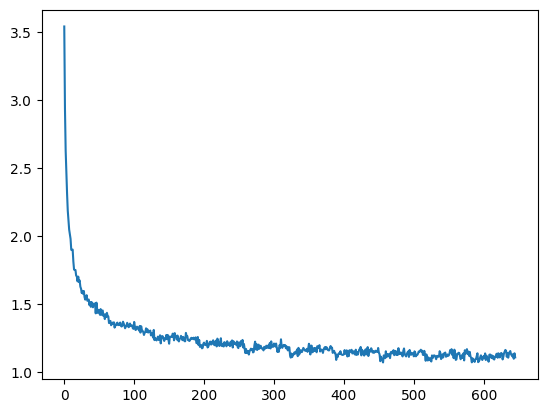

In [34]:
plt.plot(torch.tensor(l).view(-1, 10).mean(dim=-1))

In [33]:
import torch
import torch.nn as nn

vocab_size = 100
embedding_dim = 30

# 创建一个 Embedding 层
emb = nn.Embedding(vocab_size, embedding_dim)

# 查看其权重
weight = emb.weight.data  # 形状为 (100, 30)
print(f"Weight shape: {weight.shape}")
# 计算均值和标准差
mean = weight.mean().item()
std = weight.std().item()

print(f"Mean of embeddings: {mean:.6f}")
print(f"Std of embeddings: {std:.6f}")

# 计算理论上的标准差
theoretical_std = 1.0 / (vocab_size ** 0.5)
print(f"Theoretical std (1/sqrt(vocab_size)): {theoretical_std:.6f}")

Weight shape: torch.Size([100, 30])
Mean of embeddings: -0.002624
Std of embeddings: 1.008776
Theoretical std (1/sqrt(vocab_size)): 0.100000
